## 1. Conjunto de datos

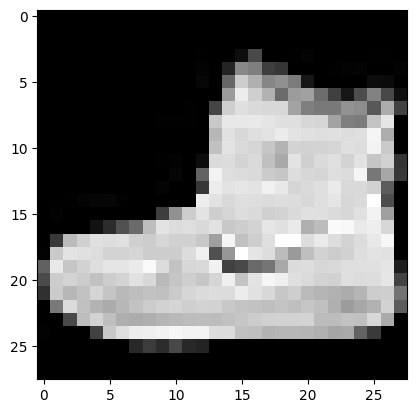

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, ConfusionMatrixDisplay
from sklearn.metrics.cluster import v_measure_score, rand_score
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from Utils import load_mnist

X_train, y_train = load_mnist(".", kind="train")
X_test, y_test = load_mnist(".", kind="t10k")
label_transcript = {0 : "T-shirt/top", 1 : "Trouser", 2 : "Pullover",
                    3 : "Dress", 4 : "Coat", 5 : "Sandal",
                    6 : "Shirt", 7 : "Sneaker", 8 : "Bag", 9 : "Ankle boot"}
num_labels = np.unique(y_train)
plt.imshow(X_train[0].reshape(28, 28), cmap = "gray")
plt.show()

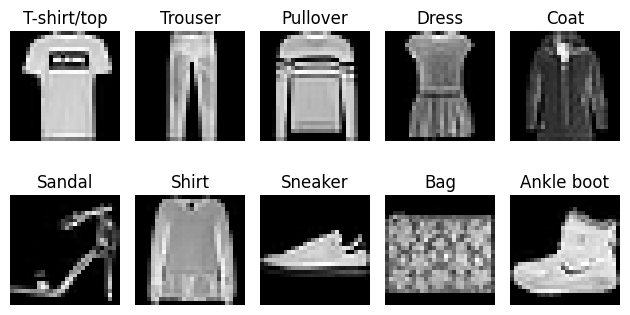

In [2]:
fig, axes = plt.subplots(2, 5)

for ax, (i, label) in zip(axes.flatten(), [(y_train.tolist().index(x), label_transcript[x]) for x in num_labels]):
    ax.imshow(X_train[i].reshape(28, 28), cmap = "gray")
    ax.set_title(label)
    ax.axis("off")
    fig.tight_layout()
plt.show()

In [3]:
print("Número de instancias por clase:")
for i in num_labels:
    print(label_transcript[i], np.count_nonzero(y_train == i))


Número de instancias por clase:
T-shirt/top 6000
Trouser 6000
Pullover 6000
Dress 6000
Coat 6000
Sandal 6000
Shirt 6000
Sneaker 6000
Bag 6000
Ankle boot 6000


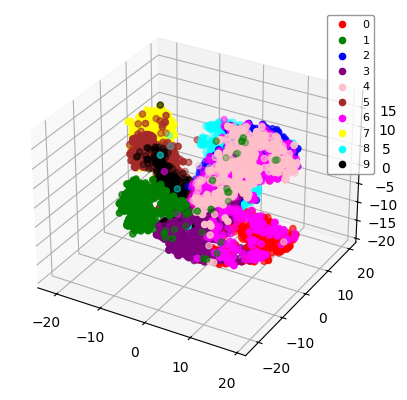

In [4]:
def draw(pts, labels):
    ulab = np.unique(labels)
    colors = dict(zip(ulab, ["red", "green", "blue", "purple", "pink", "brown", "magenta", "yellow", "cyan", "black"]))
    fig = plt.figure()
    if np.shape(pts)[1] == 3:
        ax = fig.add_subplot(projection="3d")
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], pts[:, 2][mask], c=colors[key], label = key)
    else:
        ax = fig.add_subplot()
        for key in colors:
            mask = [i == key for i in labels]
            ax.scatter(pts[:, 0][mask], pts[:, 1][mask], c=colors[key], label = key,)
            midpoint = np.median(pts[mask], axis=0)
            plt.text(midpoint[0], midpoint[1], key, fontsize=15, color="darkgray")
    plt.legend(fontsize=8, frameon=True, framealpha=0.8, edgecolor='gray')
    plt.show()
tsne = TSNE(3)
show_data = tsne.fit_transform(X_train[::10])
draw(show_data, y_train[::10])


## 2. Determinación del número de agrupamientos

#### Realizamos el agrupamiento (clustering) mediante el uso del método [$k$-medias], con inicialización aleatoria de centroides. Para determinar el mejor valor de $k$ probaremos con valores entre 1 y 15 y se guardaremos en una lista la medida de inercia de cada uno de los modelos:

In [5]:
inertias = []
K = np.arange(1, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(X_train)
    inertias.append(kmeans.inertia_)

#### Mostramos gráficamente el valor de la inercia con los valores de $k$ entre 1 y 15 para poder determinar el mejor valor de $k$ mediante el método del codo.

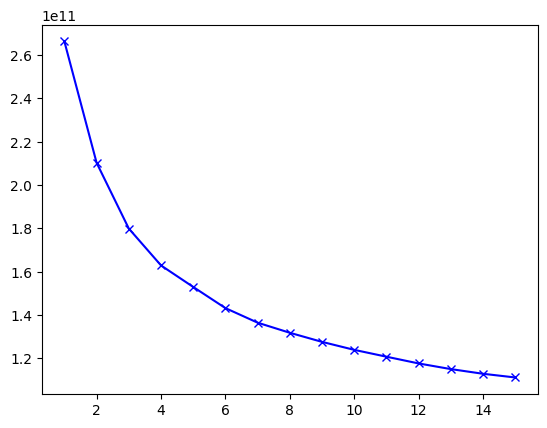

In [6]:
plt.plot(K, inertias, color="blue", marker="x")
plt.show()

#### Cálculo del coeficiente de silueta (Silhouette Coefficient). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de coeficiente para cada uno de los modelos:

In [ ]:
sil = []
K = np.arange(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(X_train)
    sil.append(silhouette_score(X_train, kmeans.labels_))
plt.plot(K, sil, color="blue", marker="x")
plt.show()

#### Cálculo de la medida V (V measure). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de la medida para cada uno de los modelos:

In [ ]:
v = []
K = np.arange(2, 16)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, init="random", n_init="auto").fit(X_train)
    v.append(v_measure_score(y_train, kmeans.labels_))
plt.plot(K, v, color="blue", marker="x")
plt.show()

##### Reentrenamos nuevamente con ese mejor valor de $k$ y mostramos centroides de los agrupamientos en dicha ejecución.

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=5, init="random", n_init="auto").fit(X_train)

fig, axes = plt.subplots(2, 5)
for ax, centr in zip(axes.flatten(), kmeans.cluster_centers_):
    ax.imshow(centr.reshape(28, 28), cmap = "gray")
    ax.axis("off")
    fig.tight_layout()
plt.show()